In [1]:
	import numpy as np
	from sklearn.datasets import make_classification
	
	# Create dummy data
	# The output of make_classification consists of feature data X and labels y
	# The labels y will be encoded (numerical) data
	X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)
	
	# By default, make_classification produces float values
	# We need to convert them to discrete form
	
	# Take the absolute value of the values
	X = np.absolute(X)
	
	# Round values to two decimal places
	# Multiply by 100 so that there are no decimal points
	X = np.round(X, 2) * 100
	
	# Convert to integer type
	X = X.astype(int)
	
	# Check the result
	print(X)
	print(y)

[[143 193]
 [ 88 118]
 [ 85  54]
 [102  79]
 [ 60  26]
 [122 126]
 [202 304]
 [ 55  51]
 [ 59   1]
 [ 21  36]
 [159 148]
 [112 122]
 [ 62  59]
 [160  20]
 [104 424]
 [149 175]
 [ 43 120]
 [110 249]
 [ 54  42]
 [ 42 176]
 [ 19 105]
 [ 74 210]
 [137  74]
 [215  56]
 [134  98]
 [196  16]
 [233  31]
 [ 49  91]
 [119 103]
 [198  64]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [2]:
import pandas as pd

# Reshape label y into 2D
# This is done because we will concatenate it with the feature data X
y_new = y.reshape(len(y), 1)

# Concatenate features X and label y into an array
data = np.concatenate((X, y_new), axis=1)

# Define column names
nama_kolom = ['Feature 1', 'Feature 2', 'Label']

# Create DataFrame
df = pd.DataFrame(data, columns=nama_kolom)

# Inspect the DataFrame
df.head()

,Feature 1,Feature 2,Label
0,143,193,0
1,88,118,0
2,85,54,0
3,102,79,0
4,60,26,0


In [3]:
# Define label names
labels = {
	1 : 'Class A',
	0 : 'Class B'
}
	
df_label = df.copy()
df_label['Label'] = df_label['Label'].map(labels)
	
print(df_label['Label'].value_counts())

	# Inspect the df_label DataFrame
df_label.head()

Label
Class B    15
Class A    15
Name: count, dtype: int64


,Feature 1,Feature 2,Label
0,143,193,Class B
1,88,118,Class B
2,85,54,Class B
3,102,79,Class B
4,60,26,Class B


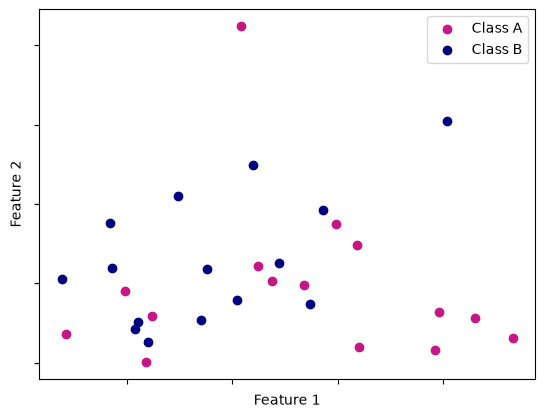

In [4]:
import matplotlib.pyplot as plt
	
# Group labels by class name
gb = df_label.groupby('Label')

class_a = gb.get_group('Class A')
class_b = gb.get_group('Class B')

colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

# Plot
plt.scatter(x=class_a['Feature 1'], y=class_a['Feature 2'], c=colors['class_a'])
plt.scatter(x=class_b['Feature 1'], y=class_b['Feature 2'], c=colors['class_b'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(['Class A', 'Class B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

In [5]:
	from sklearn.naive_bayes import MultinomialNB # class for the MultinomialNB model
	from sklearn.model_selection import train_test_split
	from sklearn.metrics import accuracy_score # evaluate the model using accuracy
	
	# Instantiate a MultinomialNB object
	mnb = MultinomialNB()
	
	# We can directly use the feature matrix X and labels y
	# resulting from the dummy data generation process
	
	# Split training and testing data
	X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)
	
	# Fit the model
	# The label y must be in 1D form or (n_samples,)
	mnb.fit(X_train, y_train)
	
	# Predict on training data
	y_train_pred = mnb.predict(X_train)
	
	# Evaluate training accuracy
	acc_train = accuracy_score(y_train, y_train_pred)
	
	# Predict test data
	y_test_pred = mnb.predict(X_test)
	
	# Evaluate the model using the accuracy metric
	acc_test = accuracy_score(y_test, y_test_pred)
	
	# Print evaluation results
	print(f'Training accuracy: {acc_train}')
	print(f'Test accuracy: {acc_test}')

Training accuracy: 0.5238095238095238
Test accuracy: 0.8888888888888888


In [6]:
	from sklearn.naive_bayes import GaussianNB # class for the GaussianNB model
	
	# Instantiate a Gaussian object
	gnb = GaussianNB()
	
	# We use the same training and testing split
	# as used for the multinomial model
	
	# Fit the model
	# The label y must be in 1D form or (n_samples,)
	gnb.fit(X_train, y_train)
	
	# Predict on training data
	y_train_pred_gnb = gnb.predict(X_train)
	
	# Evaluate training accuracy
	acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)
	
	# Predict test data
	y_test_pred_gnb = gnb.predict(X_test)
	
	# Evaluate the model using the accuracy metric
	acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)
	
	# Print evaluation results
	print(f'Training accuracy (Gaussian): {acc_train_gnb}')
	print(f'Test accuracy (Gaussian): {acc_test_gnb}')

Training accuracy (Gaussian): 0.7619047619047619
Test accuracy (Gaussian): 0.4444444444444444
